# **CNN (EfficientNet B3)**

EfficientNet refers to a family of CNN models (B0–B7) that you use for image classification, but these models were not designed manually—they were created using a smart compound scaling algorithm. This algorithm determines how to expand a model’s width, depth, and input resolution in a balanced and efficient way, so accuracy improves without wasting computation. The algorithm is used only during architecture design, while the thing you actually use is the pretrained EfficientNet model, loaded through TensorFlow (e.g., tf.keras.applications.EfficientNetB0(...)) for prediction and transfer learning.

In this coral-reef multi-label classification project, I selected EfficientNetB3 because it offers an excellent balance of accuracy, efficiency, and feature richness. EfficientNet models are created using a compound scaling algorithm that automatically balances network depth, width, and image resolution, and B3 provides noticeably stronger representational power than smaller variants like B0 or B1 while remaining lightweight enough for fast training on Colab. By leveraging the pretrained ImageNet weights, EfficientNetB3 serves as a powerful feature extractor that improves generalization, helps handle class imbalance, and boosts prediction performance on challenging underwater coral images.

In [1]:
# =====================================================================
# Import libraries
# =====================================================================

# System utilities
import os
import sys
from pathlib import Path

# Data analysis
import pandas as pd
import numpy as np

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Deep learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras import layers, models

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Clone a specific branch ("EfficientNetB3_Peng") from the GitHub repo.
# This will create a folder named 'coral-reef-classification' in /content
!git clone -b EfficientNetB3_Peng https://github.com/seanmcgowanx/coral-reef-classification.git

Cloning into 'coral-reef-classification'...
remote: Enumerating objects: 429, done.
remote: Counting objects: 100% (207/207), done.
remote: Compressing objects: 100% (144/144), done.
remote: Total 429 (delta 140), reused 63 (delta 63), pack-reused 222 (from 2)
Receiving objects: 100% (429/429), 81.64 MiB | 53.62 MiB/s, done.
Resolving deltas: 100% (187/187), done.


In [ ]:
!rm -rf /content/drive #complete clean up and remount only when remount not successful

In [3]:
# Import the Google Drive module so we can mount Drive into Colab.
from google.colab import drive
# Mount Google Drive at /content/drive.
# force_remount=True ensures it overwrites any previous mount.
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [6]:
# Clone the same GitHub repository again (default branch).
# If the folder already exists, Git will show an error that the directory is not empty.
!git clone https://github.com/seanmcgowanx/coral-reef-classification.git


fatal: destination path 'coral-reef-classification' already exists and is not an empty directory.


# Environment Setup & Data Loading

Initializes project paths (local or Colab), loads the processed multi-label CSVs, and identifies the target class columns for training.

In [4]:
def in_colab():
    return "COLAB_GPU" in os.environ or "google.colab" in sys.modules

if in_colab():
    repo_path = "/content/coral-reef-classification"
    data_path = "/content/coral-reef-classification/data/processed"
else:
    repo_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
    data_path = os.path.abspath(os.path.join(repo_path, "data", "processed"))

print("Repo path:", repo_path)
print("Data path:", data_path)

train_csv = os.path.join(data_path, "final_labels_train.csv")
test_csv  = os.path.join(data_path, "final_labels_test.csv")

df_train_full = pd.read_csv(train_csv)
df_test       = pd.read_csv(test_csv)

# Identify label columns
NON_CLASS_COLS = ["image_id", "region_id", "region_name"]
CLASSES = [c for c in df_train_full.columns if c not in NON_CLASS_COLS]
NUM_CLASSES = len(CLASSES)
print("NUM_CLASSES:", NUM_CLASSES)


Repo path: /content/coral-reef-classification
Data path: /content/coral-reef-classification/data/processed
NUM_CLASSES: 16


# Stratified Train/Validation Split

Splits the full training dataset into training and validation subsets while preserving the region distribution, ensuring balanced geographic representation in both splits.

In [9]:
df_train_full["region_name"] = df_train_full["region_name"].astype(str)

train_df, val_df = train_test_split(
    df_train_full,
    test_size=0.05,
    shuffle=True,
    random_state=42,
    stratify=df_train_full["region_name"]
)

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(df_test))

Train: 2503  Val: 132  Test: 2186


# Local Image Path Builder

Constructs filepaths for each image by searching local train/val/test directories and attaches them to the dataset. Any samples with missing images are removed to ensure a fully valid training set.

In [10]:
# Root directory where images exist
IMG_ROOT = Path("/content/drive/My Drive/AAI-501-02/Final_project/dataset_yolov8_7class/images")

def find_local_path(image_id):
    """Search train/val/test folders for <image_id>.png or .jpg."""
    for sub in ["train", "val", "test"]:
        for ext in ["png", "jpg", "jpeg"]:
            p = IMG_ROOT / sub / f"{image_id}.{ext}"
            if p.exists():
                return str(p)
    return None

def add_local_path(df):
    df["filepath"] = df["image_id"].apply(find_local_path)
    return df

train_df = add_local_path(train_df)
val_df   = add_local_path(val_df)
df_test  = add_local_path(df_test)

# remove missing
train_df = train_df[train_df["filepath"].notna()]
val_df   = val_df[val_df["filepath"].notna()]
df_test  = df_test[df_test["filepath"].notna()]


# Convert DataFrames to NumPy Arrays (X/y)

Extracts image filepaths (X) and multi-label targets (y) from each split, converting them into NumPy arrays for efficient loading during model training and evaluation.

In [11]:
def df_to_Xy(df):
    NON_CLASS_COLS = ["image_id", "filepath", "region_id", "region_name"]
    class_cols = [c for c in df.columns if c not in NON_CLASS_COLS]
    X = df["filepath"].values
    y = df[class_cols].values.astype("float32")
    return X, y

X_train, y_train = df_to_Xy(train_df)
X_val,   y_val   = df_to_Xy(val_df)
X_test,  y_test  = df_to_Xy(df_test)


# Fast Local Image Loader

Efficiently reads each image from disk, decodes PNG/JPEG formats, resizes to the target input size, and applies EfficientNet preprocessing, preparing images for training and inference.

In [12]:
PATCH_SIZE = 300

def load_image(path, label):
    img = tf.io.read_file(path)

    # detect file type
    if tf.strings.regex_full_match(path, ".*\\.png"):
        img = tf.image.decode_png(img, channels=3)
    else:
        img = tf.image.decode_jpeg(img, channels=3)

    img = tf.image.resize(img, (PATCH_SIZE, PATCH_SIZE))
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

# Data Augmentation

Defines a set of randomized image transformations—such as flips, rotations, zoom, translations, and color adjustments—to improve model robustness and reduce overfitting by simulating diverse visual conditions.

In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.10),
], name="data_aug_coral")

# Build TensorFlow Datasets

Creates efficient tf.data pipelines for training, validation, and testing by loading local images, applying preprocessing, batching, shuffling, and prefetching to ensure fast and reliable data feeding during model training.

In [14]:
BATCH_SIZE = 32

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
        .shuffle(2048)
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
)

# EfficientNetB3 Model Construction

Builds the multi-label classification model using EfficientNetB3 as a frozen feature extractor, applies on-the-fly data augmentation, adds dropout for regularization, and compiles the network with binary cross-entropy loss and multi-label AUC metrics.

In [24]:
base = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(PATCH_SIZE, PATCH_SIZE, 3)
)

base.trainable = False  # Stage 1

inputs = layers.Input((PATCH_SIZE, PATCH_SIZE, 3))
x = data_augmentation(inputs, training=True)   # AUGMENTATION HERE
x = base(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(multi_label=True, name="AUC")]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_aug_coral (Sequential)     │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │        24,592 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,808,127 (41.23 MB)

 Trainable params: 24,592 (96.06 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

# Training Callbacks

Defines model checkpoints to save the best Stage 1 and Stage 2 weights, and configures early stopping to halt training when validation AUC stops improving, ensuring optimal model selection and preventing overfitting.

In [5]:
CHECKPOINT_DIR = "/content/drive/My Drive/AAI-501-02/Final_project/effnetB3_local_clean_aug"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

stage1_ckpt = f"{CHECKPOINT_DIR}/best_stage1.keras"
stage2_ckpt = f"{CHECKPOINT_DIR}/best_stage2.keras"

check1 = tf.keras.callbacks.ModelCheckpoint(stage1_ckpt, monitor="val_AUC", mode="max", save_best_only=True)
check2 = tf.keras.callbacks.ModelCheckpoint(stage2_ckpt, monitor="val_AUC", mode="max", save_best_only=True)

early = tf.keras.callbacks.EarlyStopping(
    monitor="val_AUC",
    mode="max",
    patience=4,
    min_delta=0.001,
    restore_best_weights=True
)


# Stage 1 Training (Frozen EfficientNetB3 Backbone)

Trains only the classification head while keeping the EfficientNetB3 backbone frozen, allowing the model to learn task-specific features before fine-tuning. The best weights are saved and reloaded using the Stage 1 checkpoint.

In [28]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[check1, early]
)

print("Stage 1 completed. Loaded best model.")
model = tf.keras.models.load_model(stage1_ckpt)


Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 553s 7s/step - AUC: 0.6547 - loss: 0.4575 - val_AUC: 0.7440 - val_loss: 0.4242
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 478s 6s/step - AUC: 0.7461 - loss: 0.4184 - val_AUC: 0.7625 - val_loss: 0.4100
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 462s 6s/step - AUC: 0.7770 - loss: 0.4025 - val_AUC: 0.7788 - val_loss: 0.4048
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 440s 6s/step - AUC: 0.7867 - loss: 0.3956 - val_AUC: 0.7850 - val_loss: 0.3986
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 425s 5s/step - AUC: 0.7896 - loss: 0.3944 - val_AUC: 0.7877 - val_loss: 0.3955
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 419s 5s/step - AUC: 0.8081 - loss: 0.3792 - val_AUC: 0.7945 - val_loss: 0.3946
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 417s 5s/step - AUC: 0.8109 - loss: 0.3796 - val_AUC: 0.7950 - val_loss: 0.3900
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 421s 5s/step - AUC: 0.8151 - loss: 0.3734 - val_AUC: 0.8012 - val_loss: 0.3912
Epoch 9/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 400s 5s/step - AUC: 0.8131

# Stage 2 Training (Fine-Tuning EfficientNetB3)

Identifies the EfficientNetB3 backbone within the Stage 1 model, selectively unfreezes the top layers, and fine-tunes them with a low learning rate for improved feature adaptation. The best fine-tuned weights are saved and reloaded using the Stage 2 checkpoint.

In [16]:
model = tf.keras.models.load_model(stage1_ckpt)

In [17]:
early = tf.keras.callbacks.EarlyStopping(
    monitor="val_AUC",
    mode="max",
    patience=10,
    min_delta=0.001,
    restore_best_weights=True
)

In [18]:
print("\n====== INITIALIZING STAGE 2 FINE-TUNING ======\n")

# ------------------------------------------------------------
# Locate EfficientNetB3 backbone by name
# ------------------------------------------------------------
backbone = None

for layer in model.layers:
    if "efficientnetb3" in layer.name.lower():
        backbone = layer
        break
    if hasattr(layer, "layers"):
        for sub in layer.layers:
            if "efficientnetb3" in sub.name.lower():
                backbone = sub
                break

if backbone is None:
    raise ValueError("ERROR: EfficientNetB3 backbone not found inside model!")

print("Backbone located:", backbone.name)

# ------------------------------------------------------------
# Freeze everything first
# ------------------------------------------------------------
for layer in backbone.layers:
    layer.trainable = False

# ------------------------------------------------------------
# Unfreeze top layers
# ------------------------------------------------------------
N_UNFREEZE = 100
for layer in backbone.layers[-N_UNFREEZE:]:
    layer.trainable = True

print(f"Unfroze top {N_UNFREEZE} layers of EfficientNetB3.\n")

# ------------------------------------------------------------
# Recompile for fine-tuning
# ------------------------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(multi_label=True, name="AUC")]
)

print("Starting Stage 2 training...\n")

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[check2, early],
    verbose=1
)

# ------------------------------------------------------------
# Load best Stage 2 checkpoint
# ------------------------------------------------------------
model = tf.keras.models.load_model(stage2_ckpt)
print("\nLoaded best Stage 2 checkpoint.\n")



====== INITIALIZING STAGE 2 FINE-TUNING ======

Backbone located: efficientnetb3
Unfroze top 100 layers of EfficientNetB3.

Starting Stage 2 training...

Epoch 1/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 473s 6s/step - AUC: 0.7293 - loss: 0.6490 - val_AUC: 0.7863 - val_loss: 0.4354
Epoch 2/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 349s 4s/step - AUC: 0.7459 - loss: 0.5202 - val_AUC: 0.7680 - val_loss: 0.4649
Epoch 3/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 340s 4s/step - AUC: 0.7560 - loss: 0.4557 - val_AUC: 0.7645 - val_loss: 0.4563
Epoch 4/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 329s 4s/step - AUC: 0.7725 - loss: 0.4293 - val_AUC: 0.7690 - val_loss: 0.4406
Epoch 5/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 337s 4s/step - AUC: 0.7822 - loss: 0.4022 - val_AUC: 0.7763 - val_loss: 0.4257
Epoch 6/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 321s 4s/step - AUC: 0.8027 - loss: 0.3922 - val_AUC: 0.7830 - val_loss: 0.4157
Epoch 7/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 346s 4s/step - AUC: 0.8007 - loss: 0.3899 - val_AUC: 0.7897 - val_loss: 0.4063
Epoch 8/25
79/79 ━━━━━━━━━

# Model Evaluation — Multi-Label Classification Metrics

Generates predictions on the test set using a default 0.5 threshold, then reports standard multi-label metrics—including classification report, Micro-F1, and Macro-F1—to assess overall model performance across all benthic classes.

In [16]:
print("\n===== EVALUATING ON TEST SET =====\n")

pred_prob = model.predict(test_ds)
pred_bin  = (pred_prob > 0.5).astype(int)

print("\nClassification Report (threshold = 0.5)\n")
print(classification_report(y_test, pred_bin, target_names=CLASSES, zero_division=0))

print("Micro-F1:", f1_score(y_test, pred_bin, average="micro", zero_division=0))
print("Macro-F1:", f1_score(y_test, pred_bin, average="macro", zero_division=0))




===== EVALUATING ON TEST SET =====

69/69 ━━━━━━━━━━━━━━━━━━━━ 245s 3s/step

Classification Report (threshold = 0.5)

                          precision    recall  f1-score   support

              Macroalgae       0.38      0.61      0.47       885
                  Rubble       0.51      0.77      0.61       841
Crustose coralline algae       0.80      0.48      0.60      1433
          Bare substrate       0.70      0.13      0.22      1265
                    Sand       0.57      0.78      0.66       816
              Turf algae       0.61      0.17      0.26      1328
                 Porites       0.55      0.44      0.49       590
              Hard coral       0.24      0.16      0.19       334
              Soft coral       0.61      0.26      0.36       870
                Acropora       0.71      0.48      0.57       720
                    Tape       0.00      0.00      0.00       136
             Pocillopora       0.78      0.02      0.04       320
              Dead cor

# Per-Class AUC Analysis (ROC & PR Curves)

Computes ROC-AUC and PR-AUC scores for each individual class, providing a detailed view of model performance across both common and rare benthic categories, along with class support counts.

In [17]:
print("\n===== PER-CLASS AUC =====\n")

for i, cname in enumerate(CLASSES):

    roc_auc = tf.keras.metrics.AUC(curve="ROC")
    roc_auc.update_state(y_test[:, i], pred_prob[:, i])

    pr_auc = tf.keras.metrics.AUC(curve="PR")
    pr_auc.update_state(y_test[:, i], pred_prob[:, i])

    support = int(y_test[:, i].sum())

    print(f"{cname:20s}  ROC-AUC = {roc_auc.result():.4f} "
          f" PR-AUC = {pr_auc.result():.4f} "
          f" Support = {support}")




===== PER-CLASS AUC =====

Macroalgae            ROC-AUC = 0.4602  PR-AUC = 0.3769  Support = 885
Rubble                ROC-AUC = 0.7157  PR-AUC = 0.5990  Support = 841
Crustose coralline algae  ROC-AUC = 0.6684  PR-AUC = 0.8053  Support = 1433
Bare substrate        ROC-AUC = 0.6657  PR-AUC = 0.7009  Support = 1265
Sand                  ROC-AUC = 0.8008  PR-AUC = 0.7341  Support = 816
Turf algae            ROC-AUC = 0.5021  PR-AUC = 0.6157  Support = 1328
Porites               ROC-AUC = 0.7958  PR-AUC = 0.5548  Support = 590
Hard coral            ROC-AUC = 0.6325  PR-AUC = 0.2095  Support = 334
Soft coral            ROC-AUC = 0.6645  PR-AUC = 0.5654  Support = 870
Acropora              ROC-AUC = 0.8036  PR-AUC = 0.7192  Support = 720
Tape                  ROC-AUC = 0.3807  PR-AUC = 0.0461  Support = 136
Pocillopora           ROC-AUC = 0.7398  PR-AUC = 0.3296  Support = 320
Dead coral            ROC-AUC = 0.5553  PR-AUC = 0.1015  Support = 196
Montipora             ROC-AUC = 0.7439  PR

# Optimal Threshold Search for Each Class

Determines the best decision threshold for every class by evaluating F1 scores across a range of possible cutoffs. This improves multi-label performance by tailoring thresholds to class imbalance and prediction behavior, especially for rare benthic categories.

In [18]:
print("\n===== PER-CLASS OPTIMAL THRESHOLDS =====\n")

def find_best_threshold(y_true, y_prob, n_thresholds=200):
    """Return best F1 threshold for one class."""
    if y_true.sum() == 0:
        return None, None

    thresholds = np.linspace(0.0, 1.0, n_thresholds)
    best_t, best_f1 = 0.5, 0.0

    for t in thresholds:
        pred = (y_prob > t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return best_t, best_f1


print(f"{'Class':25s} {'Support':>8s} {'Best_t':>10s} {'Best_F1':>10s}")
print("-" * 60)

best_t = []
class_support = y_test.sum(axis=0)

for i, cname in enumerate(CLASSES):
    support = int(class_support[i])
    t_opt, f1_opt = find_best_threshold(y_test[:, i], pred_prob[:, i])

    best_t.append(0.5 if t_opt is None else t_opt)

    if t_opt is None:
        print(f"{cname:25s} {support:8d}     n/a       n/a  (no positives)")
    else:
        print(f"{cname:25s} {support:8d}   {t_opt:8.2f}   {f1_opt:10.3f}")

best_t = np.array(best_t)


===== PER-CLASS OPTIMAL THRESHOLDS =====

Class                      Support     Best_t    Best_F1
------------------------------------------------------------
Macroalgae                     885       0.03        0.578
Rubble                         841       0.51        0.617
Crustose coralline algae      1433       0.00        0.792
Bare substrate                1265       0.10        0.745
Sand                           816       0.57        0.669
Turf algae                    1328       0.00        0.756
Porites                        590       0.26        0.591
Hard coral                     334       0.17        0.322
Soft coral                     870       0.16        0.600
Acropora                       720       0.31        0.623
Tape                           136       0.00        0.117
Pocillopora                    320       0.12        0.391
Dead coral                     196       0.05        0.181
Montipora                      185       0.28        0.298
Cyanobacteria

In [19]:
# APPLY OPTIMAL THRESHOLDS
print("\nApplying per-class optimal thresholds...\n")

pred_bin_opt = (pred_prob > best_t).astype(int)

print("\nClassification Report — Optimal Thresholds\n")
print(classification_report(
    y_test,
    pred_bin_opt,
    target_names=CLASSES,
    zero_division=0
))

print("Macro-F1 (threshold=0.5):   ",
      f1_score(y_test, pred_bin, average="macro", zero_division=0))

print("Macro-F1 (optimal thresh): ",
      f1_score(y_test, pred_bin_opt, average="macro", zero_division=0))



Applying per-class optimal thresholds...


Classification Report — Optimal Thresholds

                          precision    recall  f1-score   support

              Macroalgae       0.41      0.99      0.58       885
                  Rubble       0.52      0.76      0.62       841
Crustose coralline algae       0.66      1.00      0.79      1433
          Bare substrate       0.63      0.90      0.75      1265
                    Sand       0.62      0.73      0.67       816
              Turf algae       0.61      1.00      0.76      1328
                 Porites       0.46      0.83      0.59       590
              Hard coral       0.20      0.76      0.32       334
              Soft coral       0.46      0.86      0.60       870
                Acropora       0.57      0.69      0.62       720
                    Tape       0.06      1.00      0.12       136
             Pocillopora       0.28      0.67      0.39       320
              Dead coral       0.11      0.64      0.

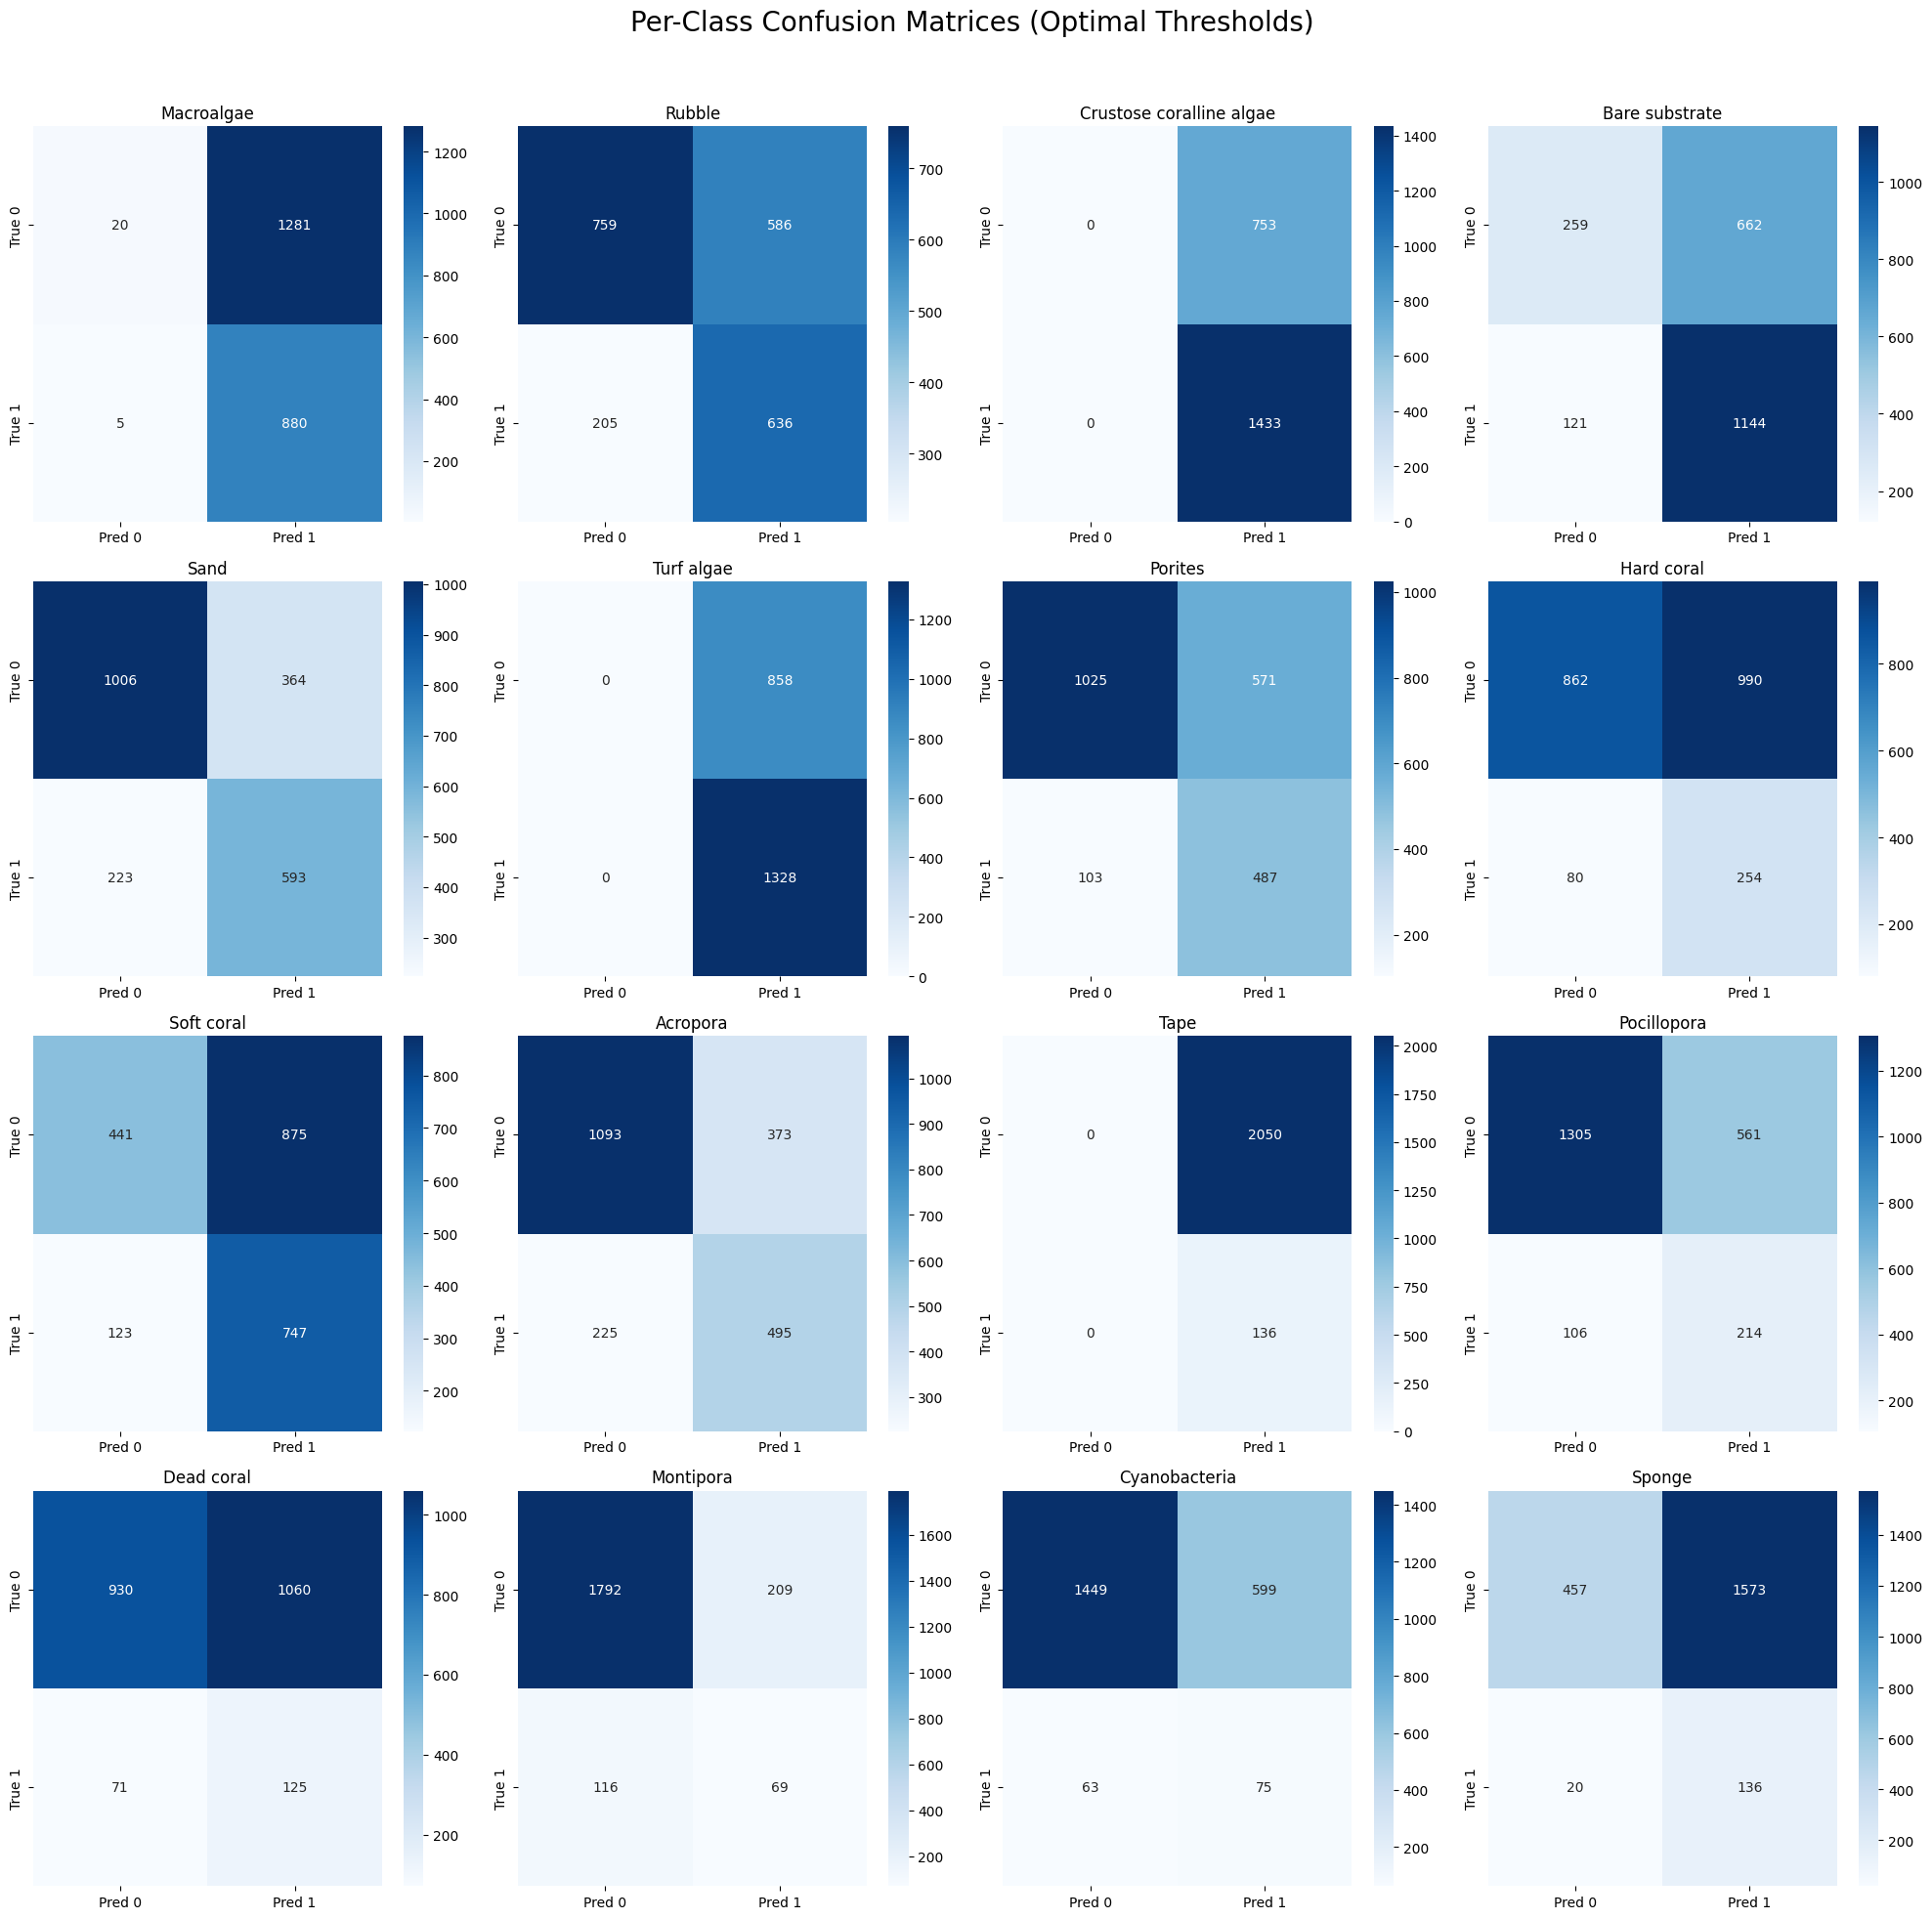

In [23]:
# CONFUSION MATRICES — PER CLASS WITH OPTIMAL THRESHOLDS

plt.figure(figsize=(20, 20))
plt.suptitle("Per-Class Confusion Matrices (Optimal Thresholds)", fontsize=20)

for i, cname in enumerate(CLASSES):
    cm = confusion_matrix(y_test[:, i], pred_bin_opt[:, i])

    plt.subplot(4, 4, i + 1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    plt.title(cname, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

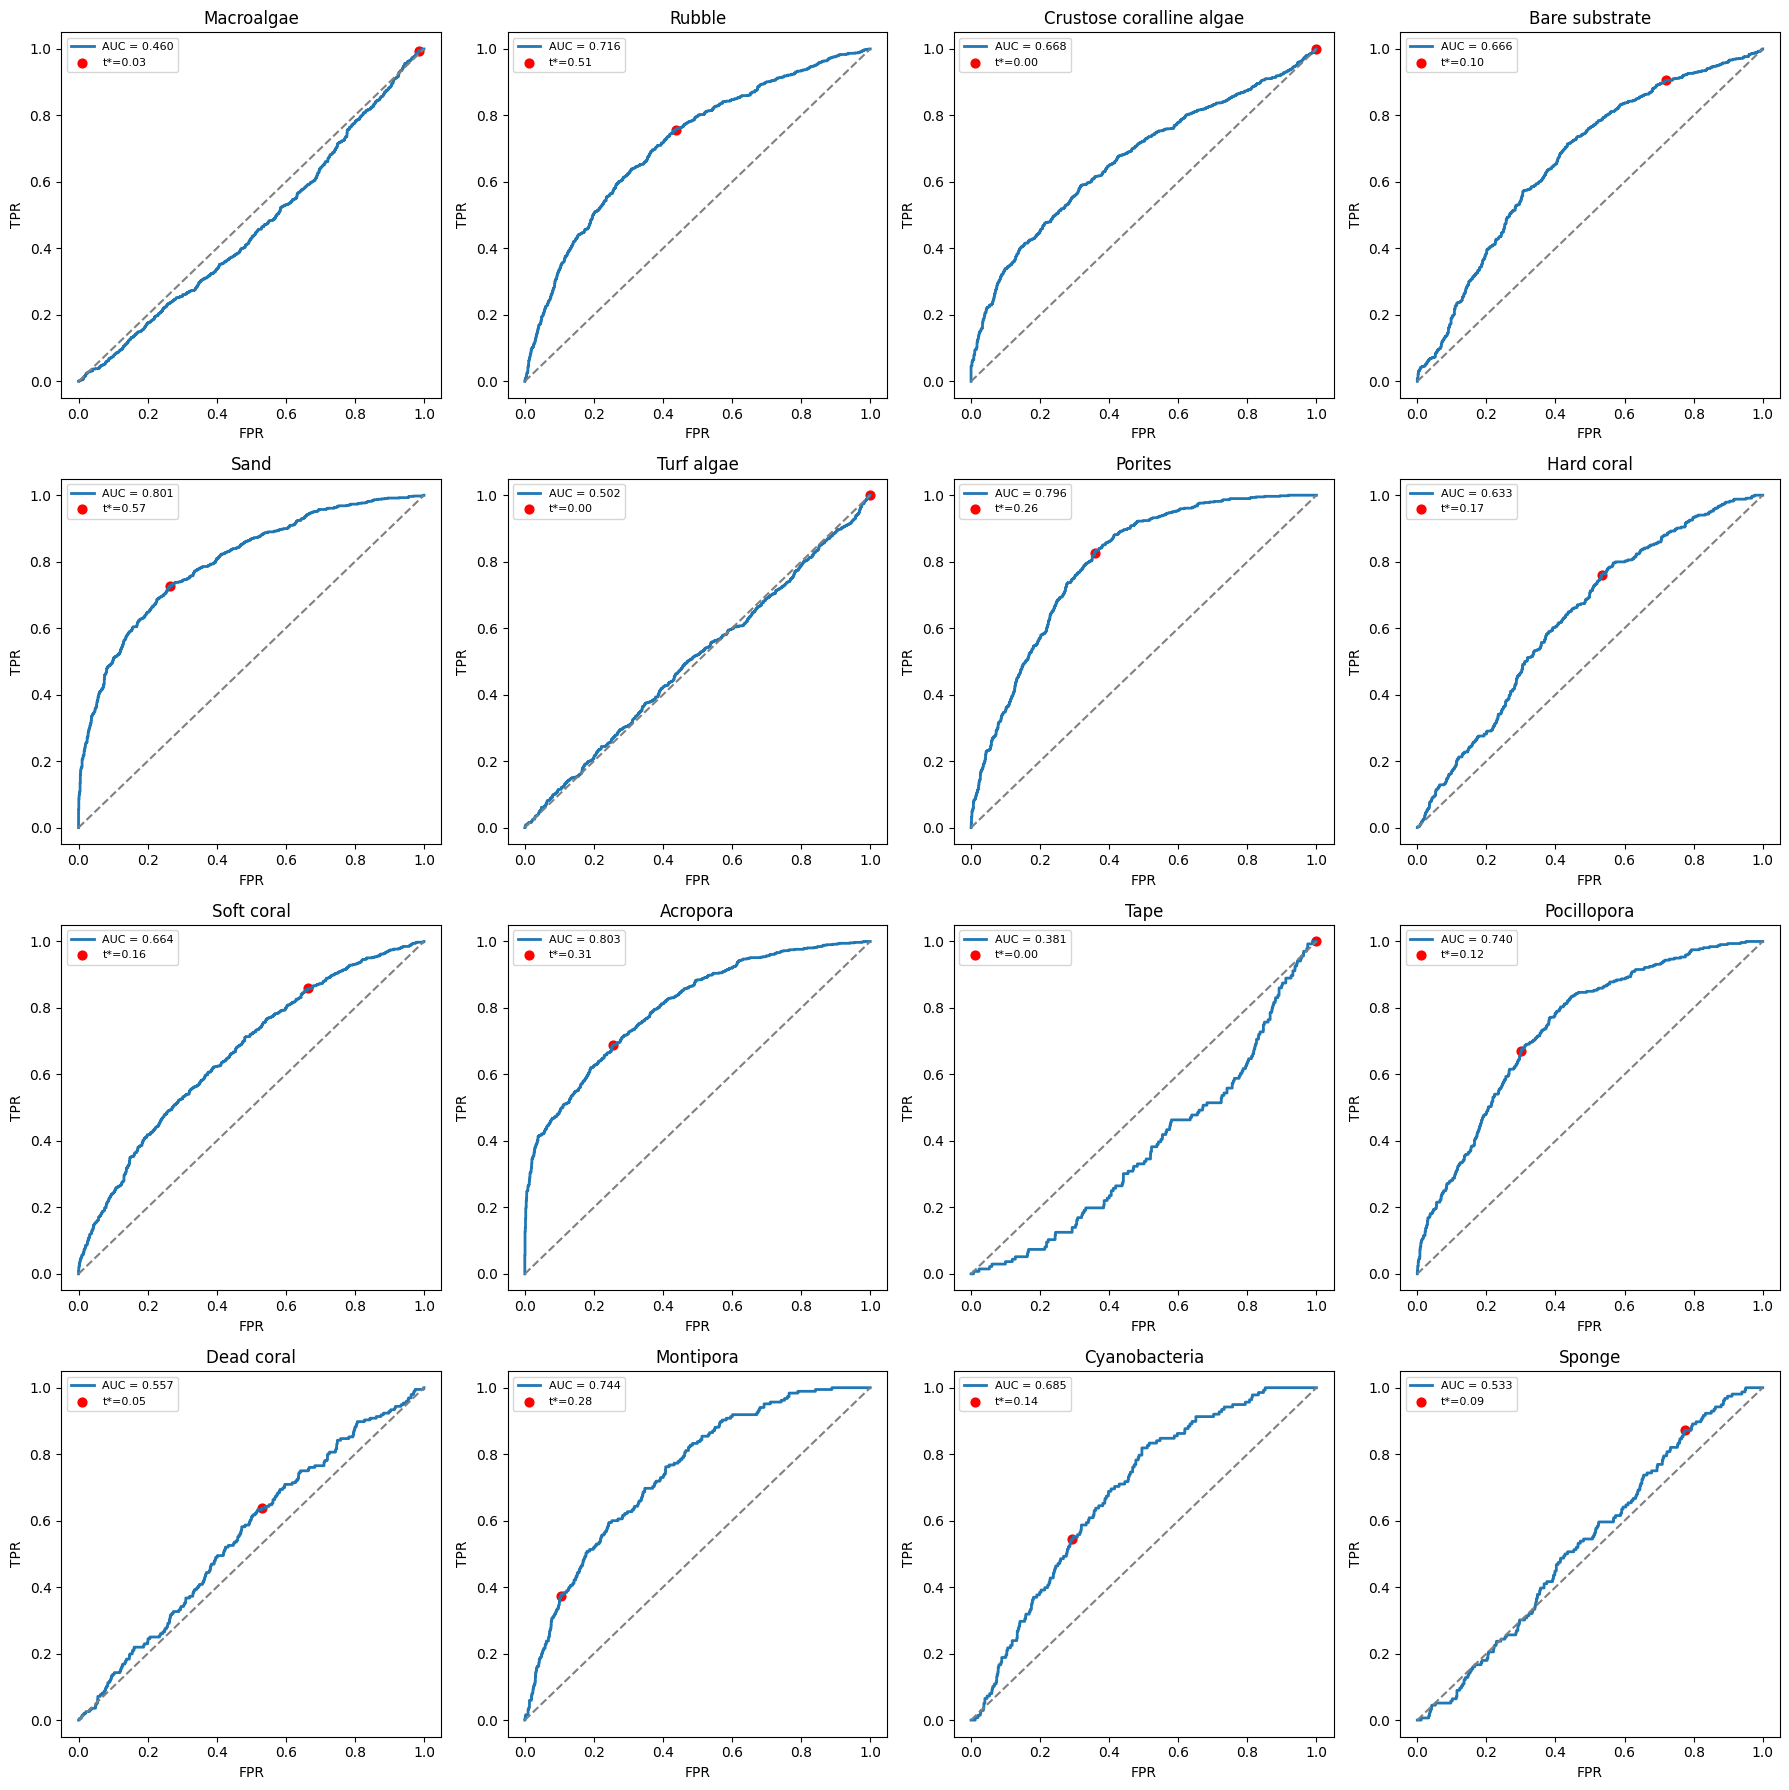

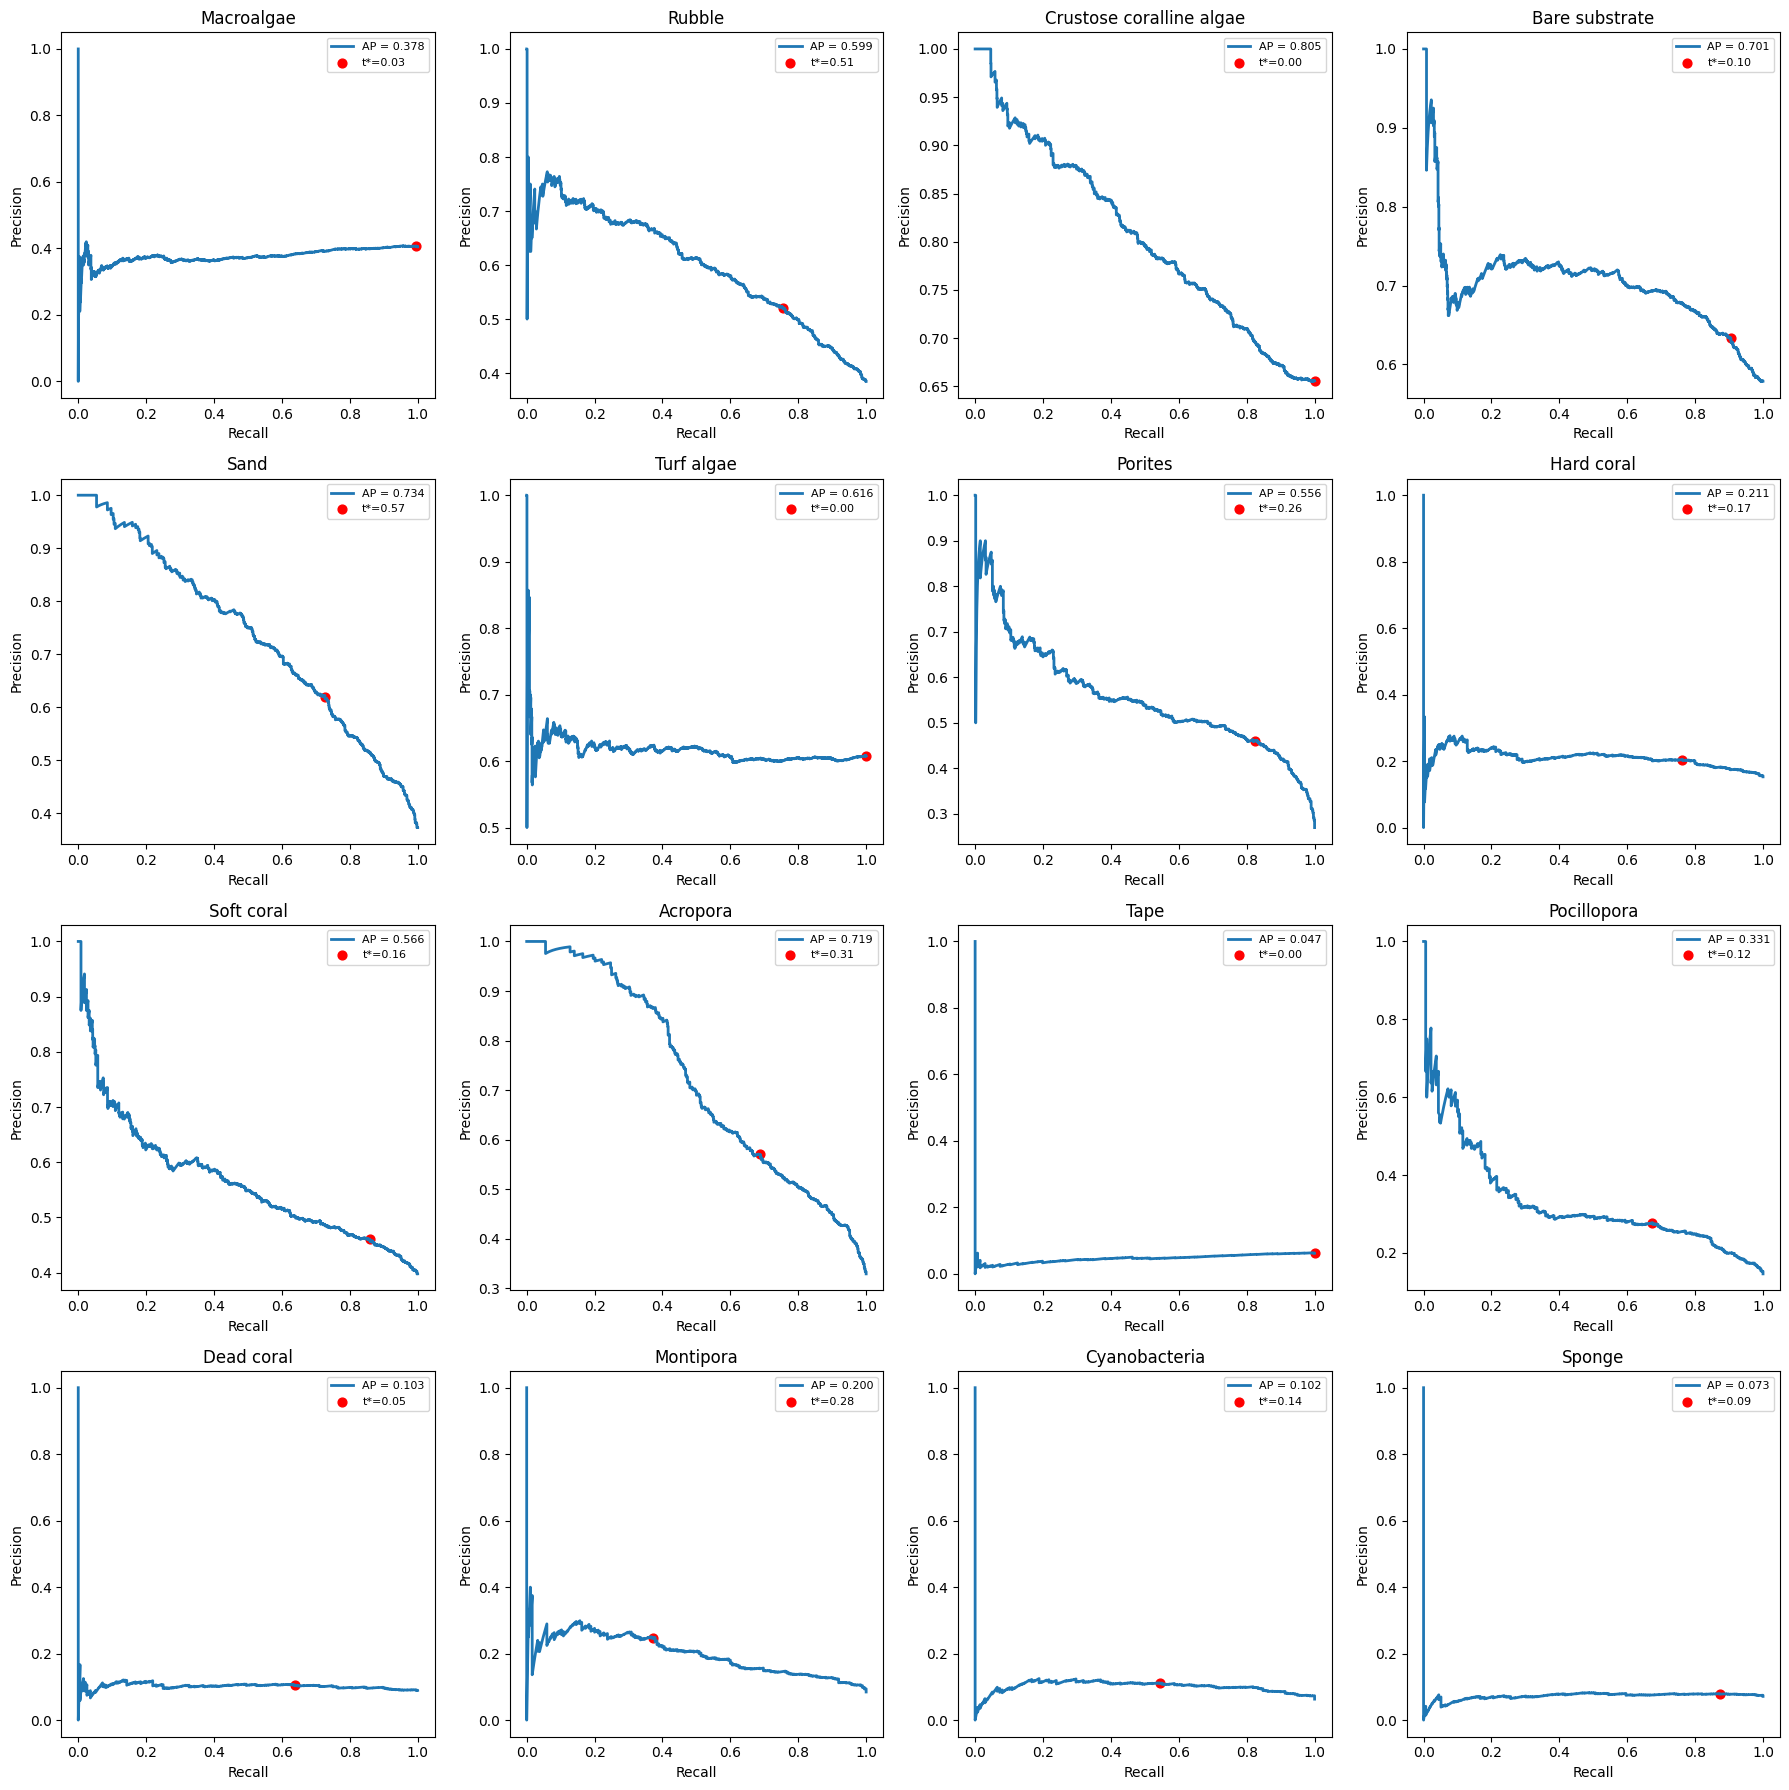

In [24]:
# ROC & PR CURVES WITH OPTIMAL THRESHOLD MARKERS

num_classes = len(CLASSES)
cols = 4
rows = int(np.ceil(num_classes / cols))


# --------------------- ROC CURVES -------------------------

fig, axes = plt.subplots(rows, cols, figsize=(18, 18))
axes = axes.flatten()

for i, cname in enumerate(CLASSES):
    ax = axes[i]
    y_true = y_test[:, i]
    y_prob = pred_prob[:, i]
    t_opt = best_t[i]

    if y_true.sum() == 0:
        ax.text(0.5, 0.5, "No Positives", ha="center", va="center")
        ax.axis("off")
        continue

    fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    idx = np.argmin(np.abs(roc_thresholds - t_opt))

    ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0,1],[0,1],"--",color="gray")

    ax.scatter(fpr[idx], tpr[idx], color='red', s=40, label=f"t*={t_opt:.2f}")

    ax.set_title(cname)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


# --------------------- PR CURVES -------------------------

fig, axes = plt.subplots(rows, cols, figsize=(18, 18))
axes = axes.flatten()

for i, cname in enumerate(CLASSES):
    ax = axes[i]
    y_true = y_test[:, i]
    y_prob = pred_prob[:, i]
    t_opt = best_t[i]

    if y_true.sum() == 0:
        ax.text(0.5, 0.5, "No Positives", ha="center", va="center")
        ax.axis("off")
        continue

    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    if t_opt <= pr_thresholds.min(): idx = 0
    elif t_opt >= pr_thresholds.max(): idx = len(pr_thresholds) - 1
    else: idx = np.argmin(np.abs(pr_thresholds - t_opt))

    ax.plot(recall, precision, lw=2, label=f"AP = {pr_auc:.3f}")
    ax.scatter(recall[idx], precision[idx], color='red', s=40,
               label=f"t*={t_opt:.2f}")

    ax.set_title(cname)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()




In [ ]:
# STAGE 1 TRAINING CURVE

train_loss_1 = history1.history["loss"]
val_loss_1   = history1.history["val_loss"]

plt.figure(figsize=(10, 6))
plt.plot(train_loss_1, label="Train Loss", lw=2)
plt.plot(val_loss_1,   label="Val Loss", lw=2)
plt.title("Stage 1 Training Curve (Frozen EfficientNetB3)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()


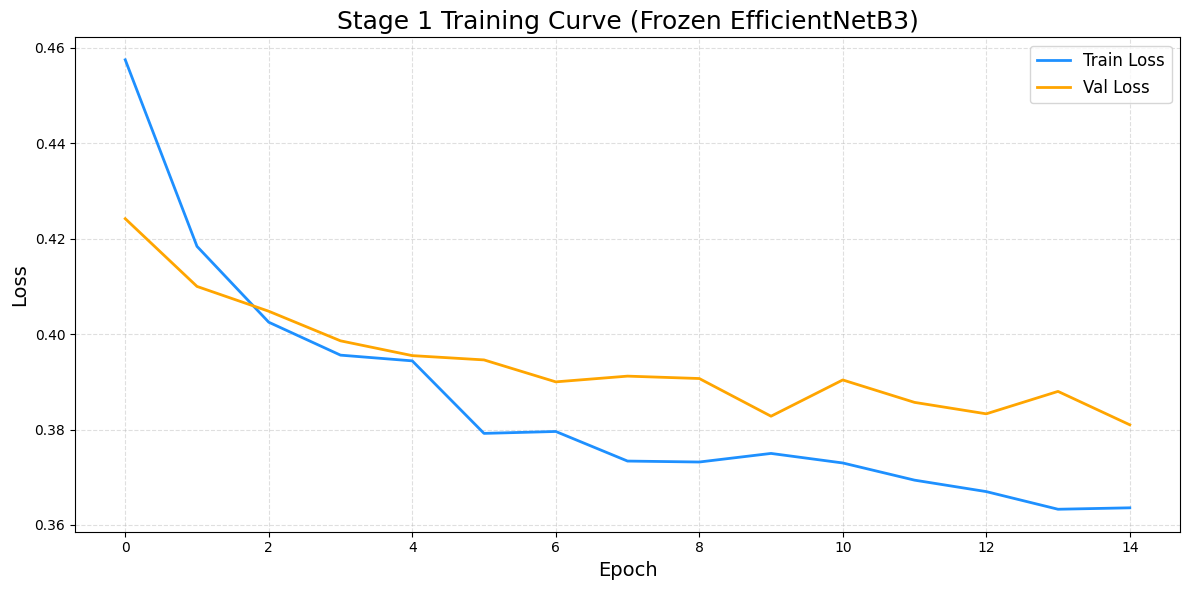

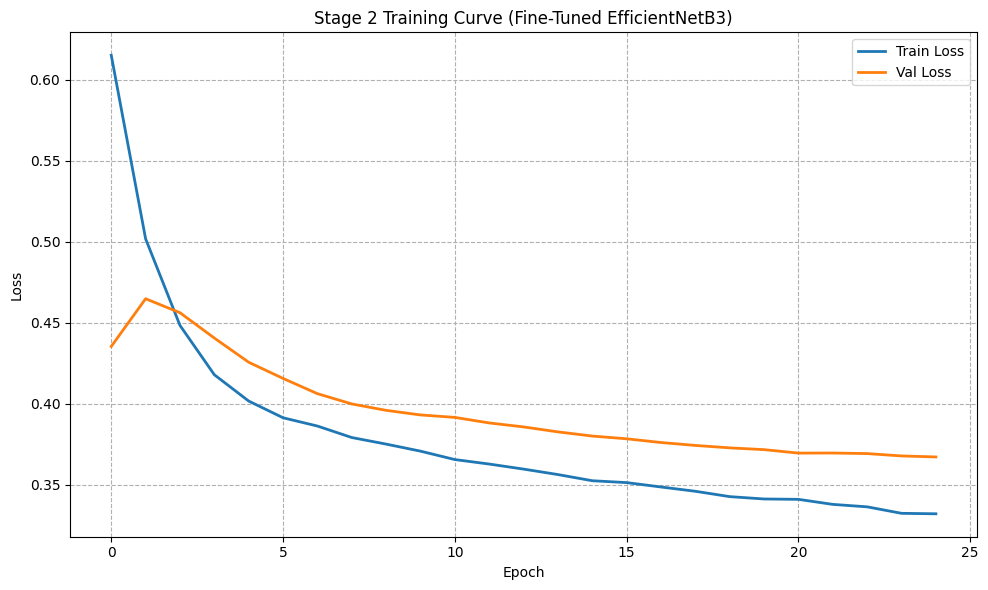

In [26]:
# STAGE 2 TRAINING CURVE

train_loss_2 = history2.history["loss"]
val_loss_2   = history2.history["val_loss"]

plt.figure(figsize=(10, 6))
plt.plot(train_loss_2, label="Train Loss", lw=2)
plt.plot(val_loss_2,   label="Val Loss", lw=2)
plt.title("Stage 2 Training Curve (Fine-Tuned EfficientNetB3)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()
